In [3]:
import numpy as np
import matplotlib.pyplot as plt
from solve_gwf_1D import solve_gwf_1D
# ------------------------------------------------------------
# Test driver (Python version of your MATLAB test_solver)
# ------------------------------------------------------------
def test_solver():
    # Choose resolution (same as MATLAB)
    K = 50
    x_cc = (np.arange(1, K+1) - 0.5) / K   # cell-centered grid

    # ------------------------------
    # TEST 1: a = 1, p = x(1-x)
    # ------------------------------
    a_fun = lambda x: 1 + 0*x
    p_fun = lambda x: x*(1-x)
    f_fun = lambda x: 2 + 0*x
    run_test("Test 1", a_fun, p_fun, f_fun, K)

    # ------------------------------
    # TEST 2: a = 1 + x, p = sin(pi x)
    # ------------------------------
    a_fun = lambda x: 1 + x
    p_fun = lambda x: np.sin(np.pi*x)
    f_fun = lambda x: -np.pi*np.cos(np.pi*x) + (np.pi**2)*(1+x)*np.sin(np.pi*x)
    run_test("Test 2", a_fun, p_fun, f_fun, K)

    # ------------------------------
    # TEST 3: a = exp(3x), p = x^2(1-x)
    # ------------------------------
    a_fun = lambda x: np.exp(3*x)
    p_fun = lambda x: x**2 * (1-x)
    f_fun = lambda x: (9*x**2 - 2) * np.exp(3*x)
    run_test("Test 3", a_fun, p_fun, f_fun, K)

    # ------------------------------
    # TEST 4: a = 0.1 + x^2, p = sin(2π x)
    # ------------------------------
    a_fun = lambda x: 0.1 + x**2
    p_fun = lambda x: np.sin(2*np.pi*x)
    f_fun = lambda x: -2*np.pi*((0.1 + x**2)*(-2*np.pi*np.sin(2*np.pi*x)) 
                                + 2*x*np.cos(2*np.pi*x))
    run_test("Test 4", a_fun, p_fun, f_fun, K)


# ------------------------------------------------------------
# Single test case (Python version of run_test in MATLAB)
# ------------------------------------------------------------
def run_test(name, a_fun, p_fun, f_fun, K):
    print(f"\n{name}")

    # Cell-centered grid
    x_cc = (np.arange(1, K+1) - 0.5) / K

    # Exact data
    coef = a_fun(x_cc)
    F    = f_fun(x_cc)
    p_ex = p_fun(x_cc)

    # Numerical solution (call your solver)
    p_num = solve_gwf_1D(coef, F)

    # Error
    err = np.max(np.abs(p_num - p_ex))
    print(f"  max error = {err:.3e}")

    # Plot
    plt.figure()
    plt.plot(x_cc, p_ex, 'k-', linewidth=4, label='Exact')
    plt.plot(x_cc, p_num, 'ro-', label='Numerical')
    plt.title(name)
    plt.legend()
    plt.xlabel("x")
    plt.ylabel("p")
    plt.grid(True)
    plt.show()



Test 1
  max error = 3.886e-16


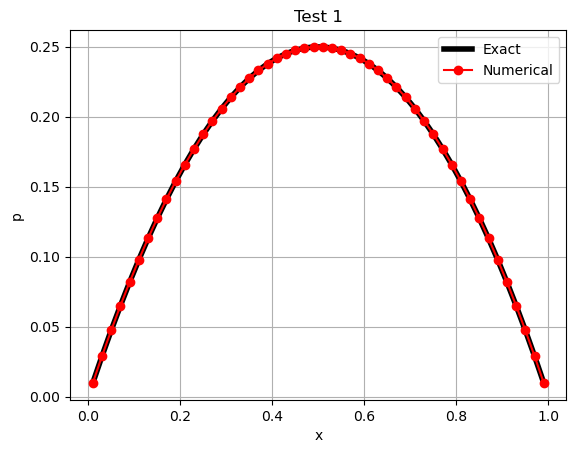


Test 2
  max error = 3.401e-04


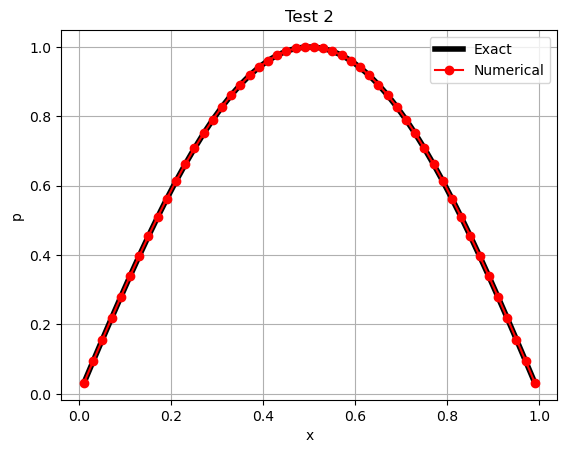


Test 3
  max error = 2.563e-04


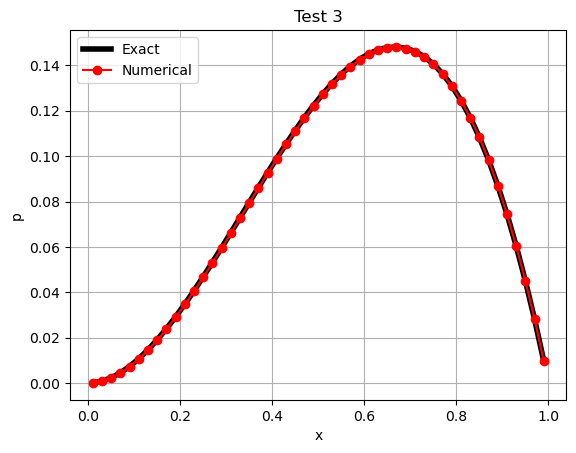


Test 4
  max error = 1.161e-03


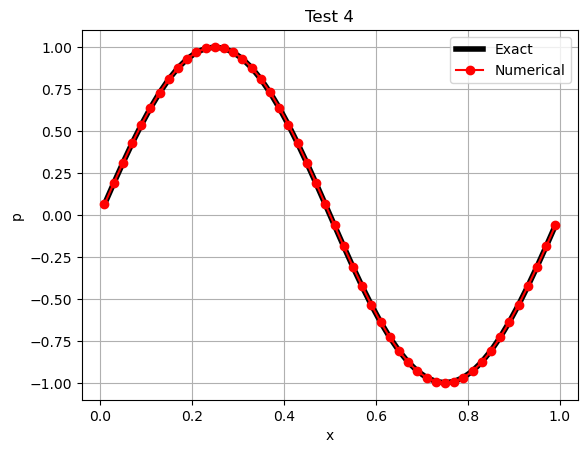

In [4]:
test_solver()
